## Create a new GP model from a collection of SNe

### Introduction

In this notebook, we will demonstrate how a user can construct their own template model surface using the `GP3D` class for an arbitrary collection of `SN` objects. This is useful, for example, if a user wants to construct their own model of a specific subtype not created in this repository already, or if they want to fit and model their own collection of new objects.

In this example, we will train a new GP model on a subset of Type IIb supernovae that contain double-peaked light curves. These unique objects are physically interesting yet difficult to identify in real time, as their initial light curve peak evolves rapidly. By constructing a model of their typical behavior, we can hope to better classify them or predict their multiwavelength evolution.

### 1. Defining our sample

First, let's construct a collection of those Type IIb supernovae in the `CAAT` database file that we know contain double-peaked light curves. If we wanted, we could plot the photometry of each Type IIb supernova to identify the ones of interest, but here we'll assume we know them already:

In [1]:
from caat import SNCollection

double_peaked_iibs = [
    "SN2020sbw",
    "SN2020rsc",
    "SN2022hnt",
    "SN2016gkg",
    "SN2021sjt",
    "SN2021pb",
    "SN2022qzr",
    "SN2011dh",
]

collection = SNCollection(names=double_peaked_iibs)

Configuration file not found:

    /Users/craigpellegrino/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.


Next, we'll normalize these objects against the total collection of Type IIb supernovae:

In [2]:
normalization_set = SNCollection(sntype="SESNe", snsubtype="SNIIb")

INFO:caat.SNCollection:Loading SN Type: SESNe, Subtype: SNIIb
INFO:caat.SNCollection:['SN2022crv' 'SN2008bo' 'SN2022ngb' 'SN2019wxt' 'SN2020sbw' 'SN2009mg'
 'SN2021uqw' 'SN2011hs' 'SN2020rsc' 'SN2022hnt' 'SN2021ybc' 'SN2016gkg'
 'SN2021sjt' 'SN2022eji' 'SN2020acat' 'SN2016bmd' 'SN2006T' 'SN2009gj'
 'SN2009mk' 'SN2020xlt' 'SN2020ikq' 'SN2021pb' 'SN2021bxu' 'SN2020jfv'
 'SN2011cb' 'SN2022qzr' 'SN2017ati' 'SN2023mut' 'SN2019hte' 'SN2019rn'
 'SN2018gk' 'SN2019tua' 'SN2011dh' 'SN2017gpn' 'SN2001gd' 'SN2006ba'
 'SN2006bf' 'SN2008aq' 'SN2008ax' 'SN2008cw' 'SN2009K']


### 2. Constructing our GP model

Now we can fit our customized sample of objects in the same fashion as any other collection of `SN` objects. We need a kernel and a choice of fitting parameters (phases, filters, and the like):

In [3]:
import numpy as np
from sklearn.gaussian_process.kernels import RBF

from caat import Kernel


kernel = Kernel(RBF([np.log(10.0), np.log10(500.0)], (2.5, 5.0)))
filts = ['UVW2', 'UVM2', 'UVW1', 'U', 'B', 'g', 'c', 'V', 'r', 'o', 'i']
phasemin = -20
phasemax = 50
log_transform = 23  # Shift the photometry by 23 days in log space
mangle_sed = True  # Use shifted wavelengths for better SED prediction
plot = True  # Plot the individual fits

Now we can do our fitting. We'll initialize a `GP3D` object, optimize the kernel hyperparameters, and finally generate our predictive model:

INFO:caat.SN:No additional data files for SN2017gpn
INFO:caat.SN:No additional data files for SN2017gpn


Optimized kernel hyperparameters: [2.5 2.5]


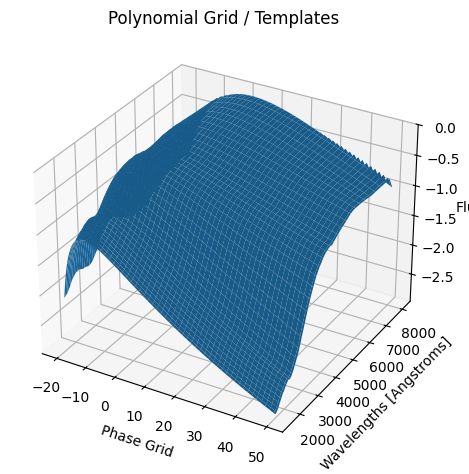

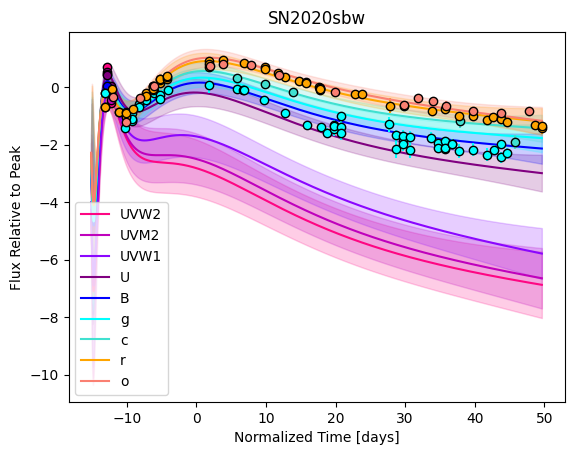

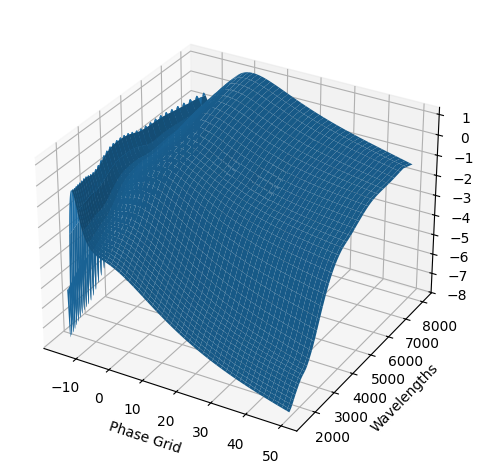

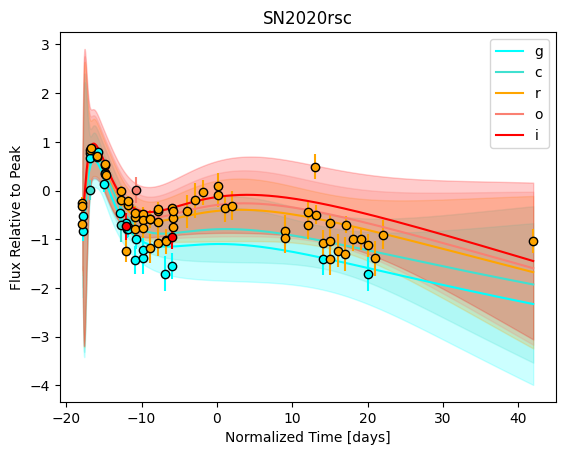

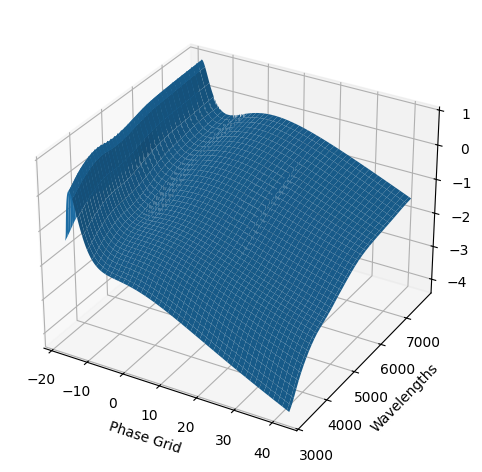

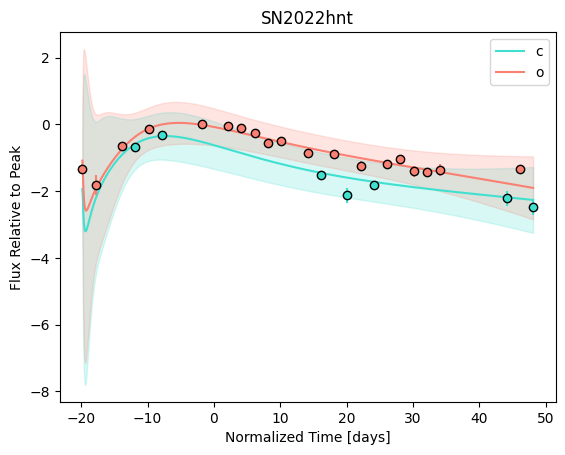

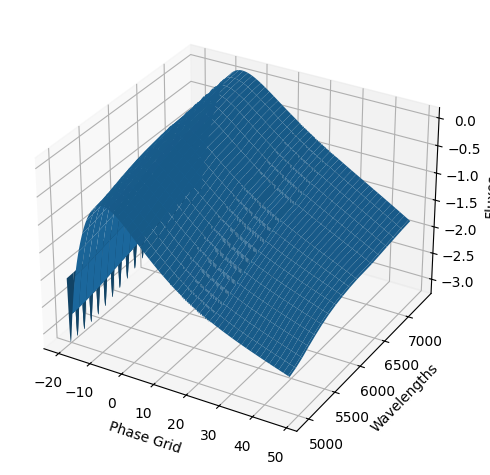

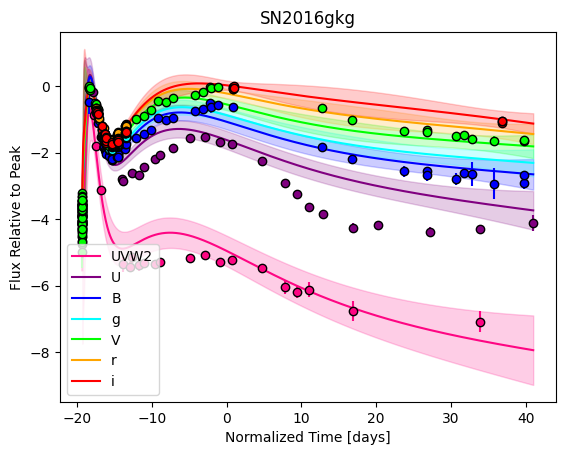

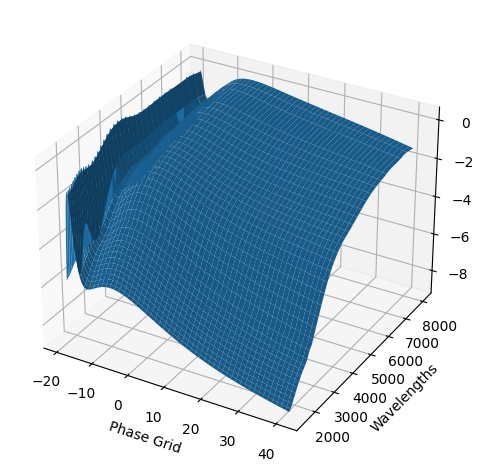

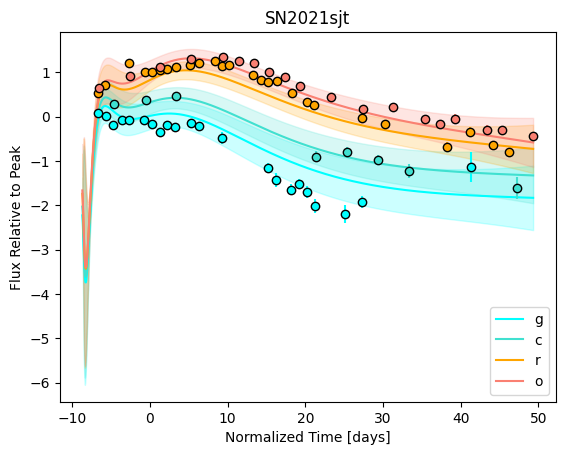

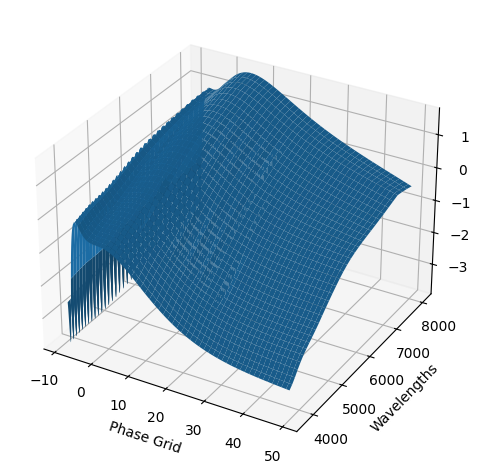

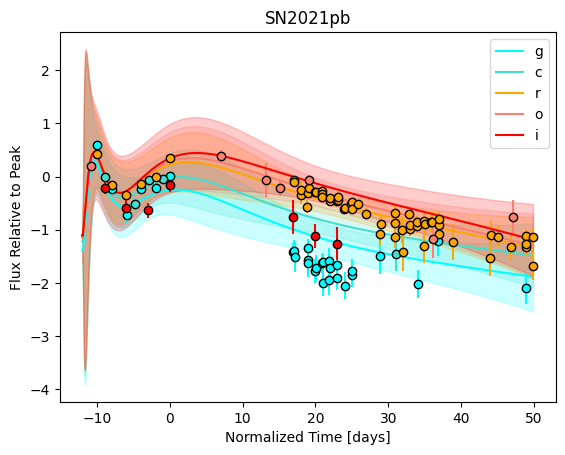

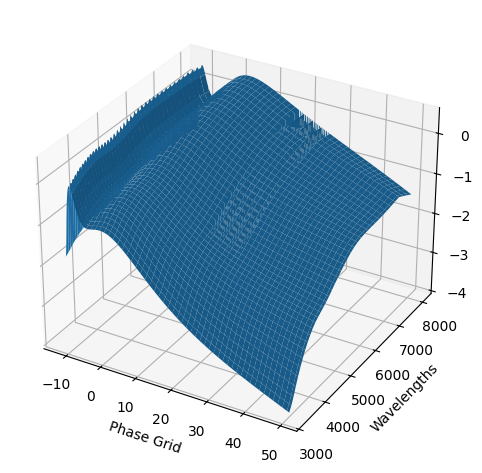

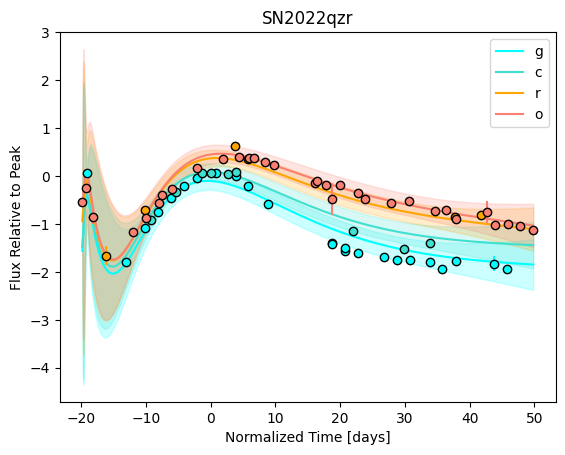

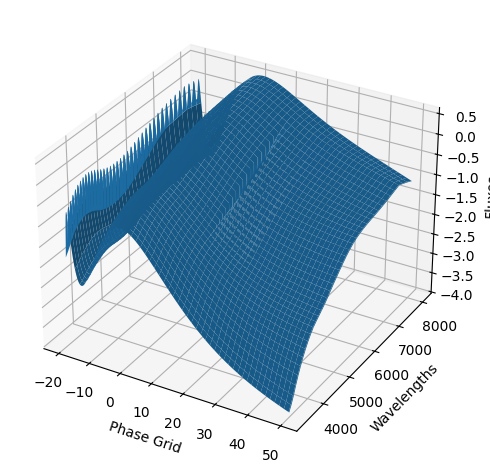

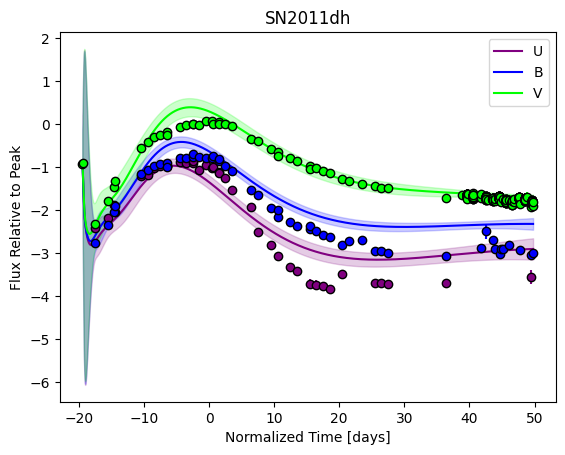

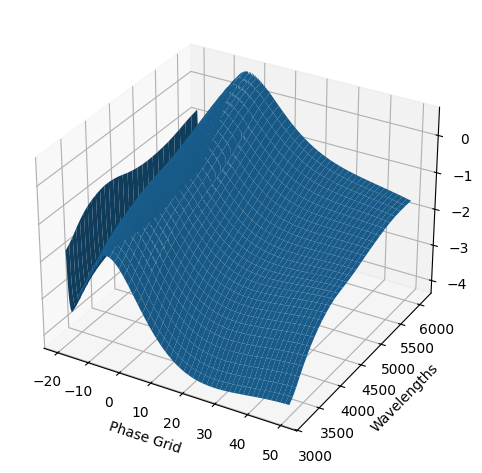

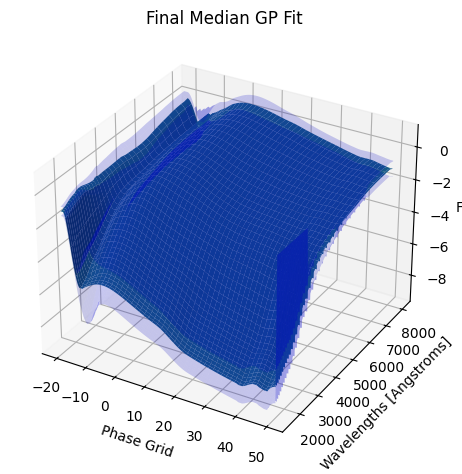

In [4]:
from caat import GP3D

gp = GP3D(
    collection=collection,
    kernel=kernel,
    filtlist=filts,
    phasemin=phasemin,
    phasemax=phasemax,
    log_transform=log_transform,
    set_to_normalize=normalization_set,
    mangle_sed=mangle_sed,
)

kernel_hyperparams = gp.optimize_hyperparams(
    subtract_polynomial=True,
)
optimized_kernel_hyperparams = np.asarray(
    [
        np.median(
            [k[i] for k in kernel_hyperparams]
        ) for i in range(len(kernel_hyperparams[0]))
    ]
)

print(f"Optimized kernel hyperparameters: {np.exp(optimized_kernel_hyperparams)}")

snmodel = gp.predict(
    plot=True,
    subtract_polynomial=True,
    fit_separately=True,
)

### 3. Saving our new GP model

The `snmodel` variable stores the final median GP fit from the fits to the individual objects in our sample. This is a `SNModel` object, which can be used to predict light curves, SEDs, generate synthetic photometry, or fit the data of new objects.

To avoid having to run the above code each time you want to use this final template model, we can save `snmodel` as a .fits file, which we can then easily load and re-initialze to use all of its functionality. To do so, the command looks like this:

In [5]:
# snmodel.save_fits(filename="double_peaked_sne.fits", force=True)

Simply specify the name of the file, and whether to overwrite an existing file with the `force` flag, and the model will be saved in the `data/` directory in this repository. Now you can customize, save, and load new models for any collection of `SN` objects you wish!